In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, auc, average_precision_score
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score , f1_score, recall_score, precision_score, roc_auc_score, average_precision_score
from sklearn.metrics import classification_report 
from sklearn.metrics import  auc, roc_curve, precision_recall_curve

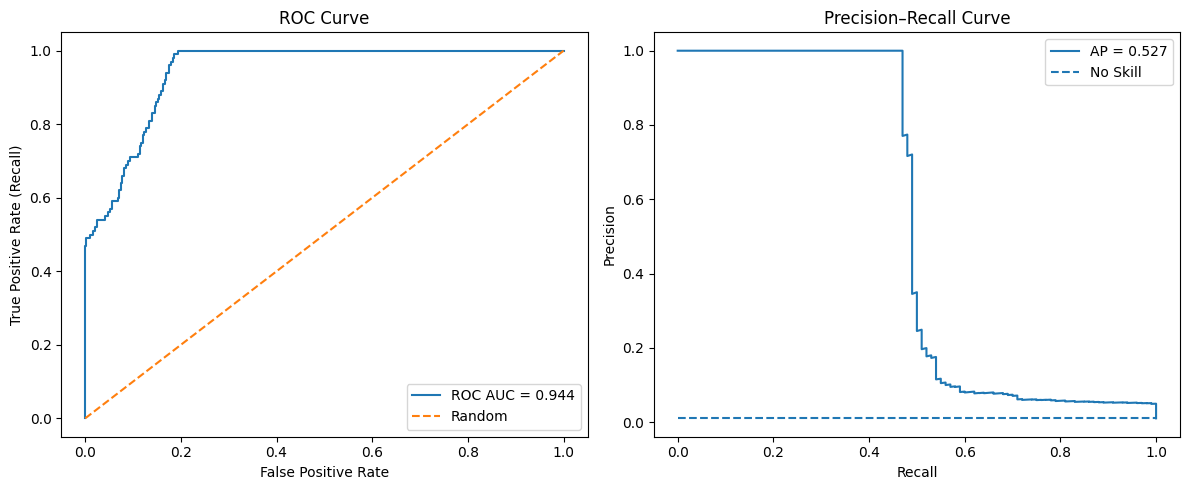

In [130]:


# Reproducibility
np.random.seed(42)

# Dataset
n_samples = 10000
n_pos = 100        # 1%
n_neg = 9900       # 99%

# True labels
y_true = np.array([1]*n_pos + [0]*n_neg)

# Model scores (weak model)
# Positives slightly higher on average
pos_scores = np.random.uniform(0.4, 0.6, n_pos)
neg_scores = np.random.uniform(0.0, 0.5, n_neg)

y_scores = np.concatenate([pos_scores, neg_scores])

# ROC
fpr, tpr, threshold = roc_curve(y_true, y_scores, drop_intermediate=True) #drops thresholds that do not change the ROC curve shape
#roc_auc = auc(fpr, tpr)
roc_auc = roc_auc_score(y_true,  y_scores)


# Precision-Recall
precision, recall, pr_threshold = precision_recall_curve(y_true, y_scores, drop_intermediate=True)
ap = average_precision_score(y_true, y_scores)

# Plot
plt.figure(figsize=(12, 5))

# ROC curve
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()

# PR curve
plt.subplot(1, 2, 2)
plt.plot(recall, precision, label=f"AP = {ap:.3f}")
plt.hlines(y=n_pos/n_samples, xmin=0, xmax=1, linestyle="--", label="No Skill")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
def get_pred_at_thres(thres):
    get_pred = lambda x: (x > thres).astype(int)
    y_pred = get_pred(y_scores)
    print(confusion_matrix(y_true, y_pred))
    print(pd.DataFrame(y_pred).value_counts())
    return y_pred

In [49]:
y_pred_1 = get_pred_at_thres(1)
print(classification_report(y_true, y_pred_1, target_names=["No", "Yes"]))

[[9900    0]
 [ 100    0]]
0
0    10000
Name: count, dtype: int64
              precision    recall  f1-score   support

          No       0.99      1.00      0.99      9900
         Yes       0.00      0.00      0.00       100

    accuracy                           0.99     10000
   macro avg       0.49      0.50      0.50     10000
weighted avg       0.98      0.99      0.99     10000



C:\Users\nedwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\nedwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\nedwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [92]:
y_pred_05 = get_pred_at_thres(0.499174)
print(classification_report(y_true, y_pred_05, target_names=["No", "Yes"]))

[[9887   13]
 [  53   47]]
0
0    9940
1      60
Name: count, dtype: int64
              precision    recall  f1-score   support

          No       0.99      1.00      1.00      9900
         Yes       0.78      0.47      0.59       100

    accuracy                           0.99     10000
   macro avg       0.89      0.73      0.79     10000
weighted avg       0.99      0.99      0.99     10000



In [91]:
youden_index = tpr - fpr  
best_threshold = threshold[youden_index.argmax()] 
print(f"Best threshold: {best_threshold}")
y_pred_best = get_pred_at_thres(best_threshold)
print(classification_report(y_true, y_pred_best, target_names=["No", "Yes"]))

Best threshold: 0.4011044234247205
[[7977 1923]
 [   1   99]]
0
0    7978
1    2022
Name: count, dtype: int64
              precision    recall  f1-score   support

          No       1.00      0.81      0.89      9900
         Yes       0.05      0.99      0.09       100

    accuracy                           0.81     10000
   macro avg       0.52      0.90      0.49     10000
weighted avg       0.99      0.81      0.88     10000



In [90]:
roc_df = pd.DataFrame([tpr, fpr, threshold]).T
roc_df.rename(columns={0:"tpr", 1:"fpr", 2:"threshold"}, inplace=True)

thres_arr = [roc_df["threshold"].max(), 
             roc_df["threshold"].nlargest(2).iloc[-1], #2nd largest threshold after inf
             roc_df[roc_df["fpr"]>0]["threshold"].nlargest(1).iloc[-1], #thresold of first observed fpr change
             best_threshold, # best threshold
             roc_df["threshold"].min()  
            ]

roc_df[roc_df["threshold"].isin(thres_arr)]

,tpr,fpr,threshold
0,0.00,0.000000,inf
1,0.01,0.000000,0.597377
3,0.47,0.001414,0.499174
104,1.00,0.194242,0.401104
105,1.00,1.000000,0.000006


In [ ]:
this is an imbalance class problem - 9900 negatives (no loan), 100 positives (yes loan)

roc: tpr vs fpr
* at threshold 1/inf (i.e anything >= predicted probability 1 is only considered a positive): 
    * acc 99%, but misleading. We lost 100 samples to FN which is actually TP. No punishment for ignoring positive class
    * tpr, fpr = 0, 0. Becauase no positves are present
* at threshold ~ 0.5 (i.e anything above predicted probability 0.49 is now a positve):
    * acc still at 98% 
    * TPR increases as some positives are correctly classified  
    * FPR remains low because even a few false positives are small relative to the 9900 negatives.
    * So, the ROC curve shows a steep rise in TPR with minimal FPR increase, but failing to capture the FPs
* at threshold ~ 0.40 (best threshold):
    * acc drops to 81% 
    * TPR is highest
    * FPR is still at only 0.19 ~1900 false positives

So, ROC curve says we capture almost all the TRUE positives when FPR error rate is very low (20%) - suggests strong performance — high TPR at low FPR. 
But if we look at the confusion matirix we have ~ 1900 FPs. i.e we have ~ 1900 invalid positive predictions.
ROC fails to capture this, as it only shows rates, not counts.

    
pr: pr vs tpr
* at threshold 1:
    * pr, tpr = 0, 0. No samples are predicted positive, so the classifier is useless here.
* at best threshold (~ 0.5):
    * pr = 1, tpr = 0.47. i.e All predicted positives are true positives (no false positives yet), but only 47% of the actual positives are captured., the line stays high and flat. 
    * F1 score peaks here at 0.63, balancing precision and recall.
* at threshold 0:
    * pr, tpr = 0, 1. i.e all true postives were captured (recall=1) along with all negatives predicted as positives (FP=at highest, so precision ~ 0)

The important point to note here is that at threshold ~ 0.49 we see a sharp drop in the PR curve. The precision almost goes from 1 (no FPs) to 0.22 (1 - 0.22 = 0.77 ~ 77% of FPs). 
And as the threshold keeps reducing we see increase in recall gradually but the precision keeps dropping. This graph clearly reveals us the fall of precision as we keep predicting False positives.
Because the data is imbalanced, we could identify from PR curve here that if we go past a recall of 0.47 the precision is highly affected due to the higher number of false positives we 
predict along which was not evident from the ROC curve.

This illustrates how, in imbalanced data, the PR curve clearly reveals the trade-off between recall and precision. 
Unlike the ROC curve (which can look deceptively strong), the PR curve makes it evident that once recall goes beyond ~0.47, precision deteriorates sharply due to the overwhelming number of false positives.


Takeaway:  
The PR curve is more informative than ROC in imbalanced problems because it directly shows how false positives erode precision, even when recall improves.

# PR curve

In [125]:
y_pred = get_pred_at_thres(0.5)

[[9900    0]
 [  53   47]]
0
0    9953
1      47
Name: count, dtype: int64


In [127]:
print(classification_report(y_true, y_pred, target_names=["No", "Yes"]))

              precision    recall  f1-score   support

          No       0.99      1.00      1.00      9900
         Yes       1.00      0.47      0.64       100

    accuracy                           0.99     10000
   macro avg       1.00      0.73      0.82     10000
weighted avg       0.99      0.99      0.99     10000



In [126]:
lr_f1= f1_score(y_true, y_pred)
lr_f1

0.6394557823129252

In [163]:
no_skill = len(y_true[y_true == 1]) / len(y_true)
no_skill

0.01

In [166]:
avg_precision = average_precision_score(y_true, y_scores)
print('Average precision score: {0:0.2f}'.format(avg_precision))

Average precision score: 0.53


In [182]:
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (
    precision[:-1] + recall[:-1] + 1e-9
)
best_idx = np.argmax(f1_scores)
best_pr_threshold = pr_threshold[best_idx]

pr_df = pd.DataFrame([precision,recall,f1_scores, pr_threshold]).T
pr_df.rename(columns={0:"precision",1:"recall",2:"f1_scores",3:"pr_threshold"}, inplace=True)

thres_arr = [1,
             pr_df["pr_threshold"].max(), 
             pr_df["pr_threshold"].nlargest(2).iloc[-1], #2nd largest threshold after inf
             pr_df[pr_df["precision"]>0]["pr_threshold"].nlargest(1).iloc[-1], #thresold of first observed precision change
             best_pr_threshold, # best threshold
             pr_df["pr_threshold"].min(),  
             0]

pr_df[pr_df["pr_threshold"].isin(thres_arr)].sort_values(by="pr_threshold", ascending=False)

,precision,recall,f1_scores,pr_threshold
151,1.00,0.01,0.019802,0.597377
150,1.00,0.02,0.039216,0.593982
105,1.00,0.47,0.639456,0.502847
0,0.01,1.00,0.019802,0.000006


In [169]:
y_pred_best  = get_pred_at_thres(best_pr_threshold)
print(classification_report(y_true, y_pred_best, target_names=["No", "Yes"]))

[[9900    0]
 [  54   46]]
0
0    9954
1      46
Name: count, dtype: int64
              precision    recall  f1-score   support

          No       0.99      1.00      1.00      9900
         Yes       1.00      0.46      0.63       100

    accuracy                           0.99     10000
   macro avg       1.00      0.73      0.81     10000
weighted avg       0.99      0.99      0.99     10000



In [217]:
y_pred_best  = get_pred_at_thres(0.40)
print(classification_report(y_true, y_pred_best, target_names=["No", "Yes"]))

[[7956 1944]
 [   0  100]]
0
0    7956
1    2044
Name: count, dtype: int64
              precision    recall  f1-score   support

          No       1.00      0.80      0.89      9900
         Yes       0.05      1.00      0.09       100

    accuracy                           0.81     10000
   macro avg       0.52      0.90      0.49     10000
weighted avg       0.99      0.81      0.88     10000

